In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pydosert as PDRT
from pydosert.data import Phantom
from pydosert.utils.plotting import plot_overview, plot_profiles


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

In [2]:
machine_config = PDRT.MachineConfig(number_of_leaf_pairs=10, tpr_20_10=0.73, mean_photon_energy_MeV=0.39)
phantom = PDRT.Phantom.from_uniform_water(shape=(100, 100, 100), spacing=(2.0, 2.0, 2.0))
beam = PDRT.Beam.create(
    gantry_angle_deg=0.0,
    number_of_leaf_pairs=10, 
    field_size_mm=(100.0, 100.0),
    iso_center=(100.0, 100.0, 100.0)
)
engine = PDRT.DoseEngine(
    machine_config=machine_config,
    dose_grid_spacing=phantom.resolution,
    dose_grid_shape=phantom.density_image.shape,
    kernel_size=75,
    beam_template=beam,
    device=device,
    dtype=dtype)
engine.calibrate(110)
phantom = phantom.to(engine.dtype).to(engine.device)
beam = beam.to(engine.device).to(engine.dtype)
dose_lr = engine.compute_dose(beam, density_image=phantom.density_image).detach().cpu().numpy()

Calibration failed. Adjusting calibration factor to: 0.002482578559661828


In [3]:
machine_config = PDRT.MachineConfig(number_of_leaf_pairs=10, tpr_20_10=0.73, mean_photon_energy_MeV=0.39)
phantom = PDRT.Phantom.from_uniform_water(shape=(200, 200, 200), spacing=(1.0, 1.0, 1.0))
beam = PDRT.Beam.create(
    gantry_angle_deg=0.0,
    number_of_leaf_pairs=10, 
    field_size_mm=(100.0, 100.0),
    iso_center=(100.0, 100.0, 100.0)
)
engine = PDRT.DoseEngine(
    machine_config=machine_config,
    dose_grid_spacing=phantom.resolution,
    dose_grid_shape=phantom.density_image.shape,
    beam_template=beam,
    kernel_size=151,
    device=device,
    dtype=dtype)
engine.calibrate(110)
phantom = phantom.to(engine.dtype).to(engine.device)
beam = beam.to(engine.device).to(engine.dtype)
dose_hr = engine.compute_dose(beam, density_image=phantom.density_image).detach().cpu().numpy()


Calibration failed. Adjusting calibration factor to: 0.0013289875126638133


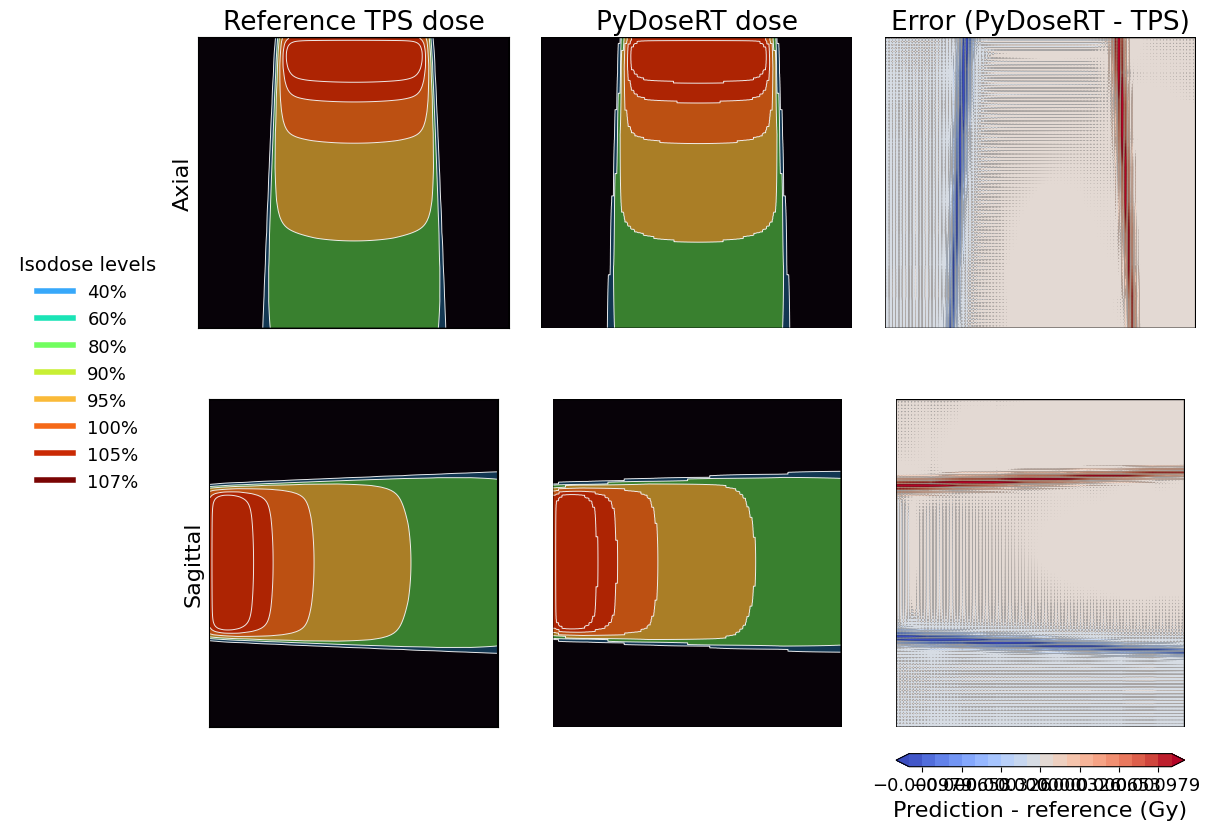

In [4]:
import torch

# Upsample the low-res dose onto the high-res grid, then compare as reference vs prediction.
lr_up = np.repeat(np.repeat(np.repeat(dose_lr[0], 2, 0), 2, 1), 2, 2)
ph = Phantom.from_uniform_water(shape=dose_hr.shape[1:], spacing=(1.0, 1.0, 1.0))
ph.dose = torch.from_numpy(dose_hr[0])
ph.add_mask("External", torch.ones(dose_hr.shape[1:], dtype=torch.bool), overwrite=True)
plot_overview(ph, dose_pred=torch.from_numpy(lr_up), dvh=False)

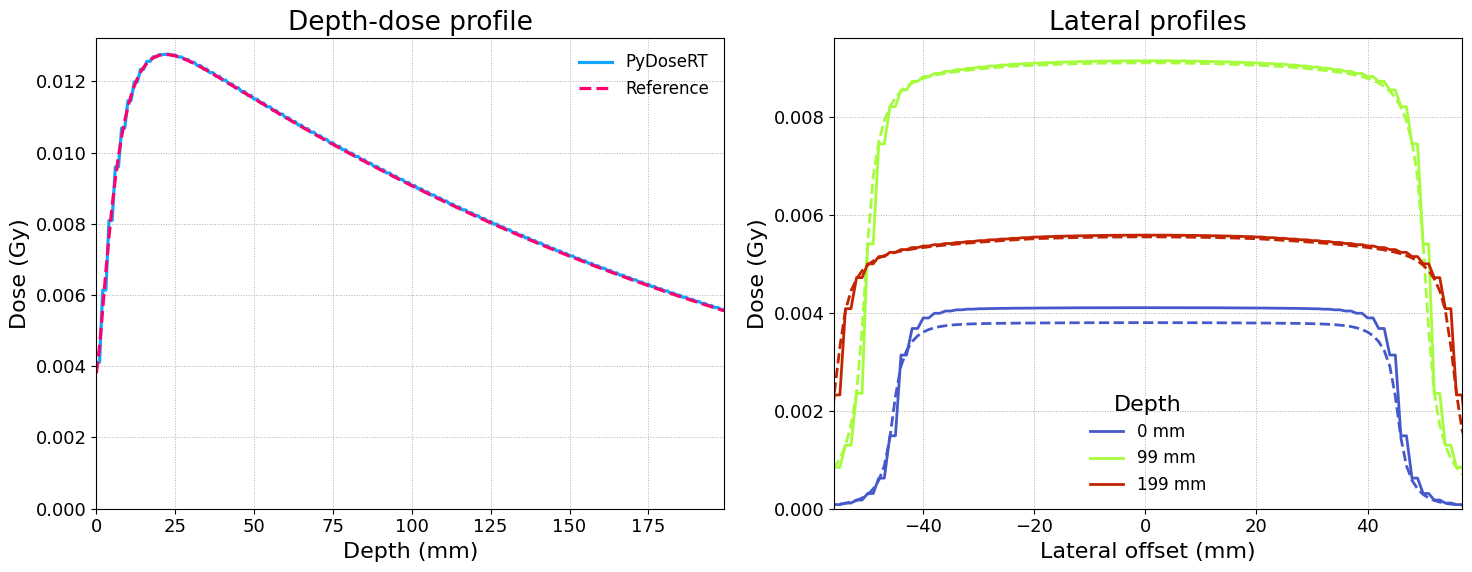

In [5]:
plot_profiles(ph, dose_pred=torch.from_numpy(lr_up), depth_axis=1)

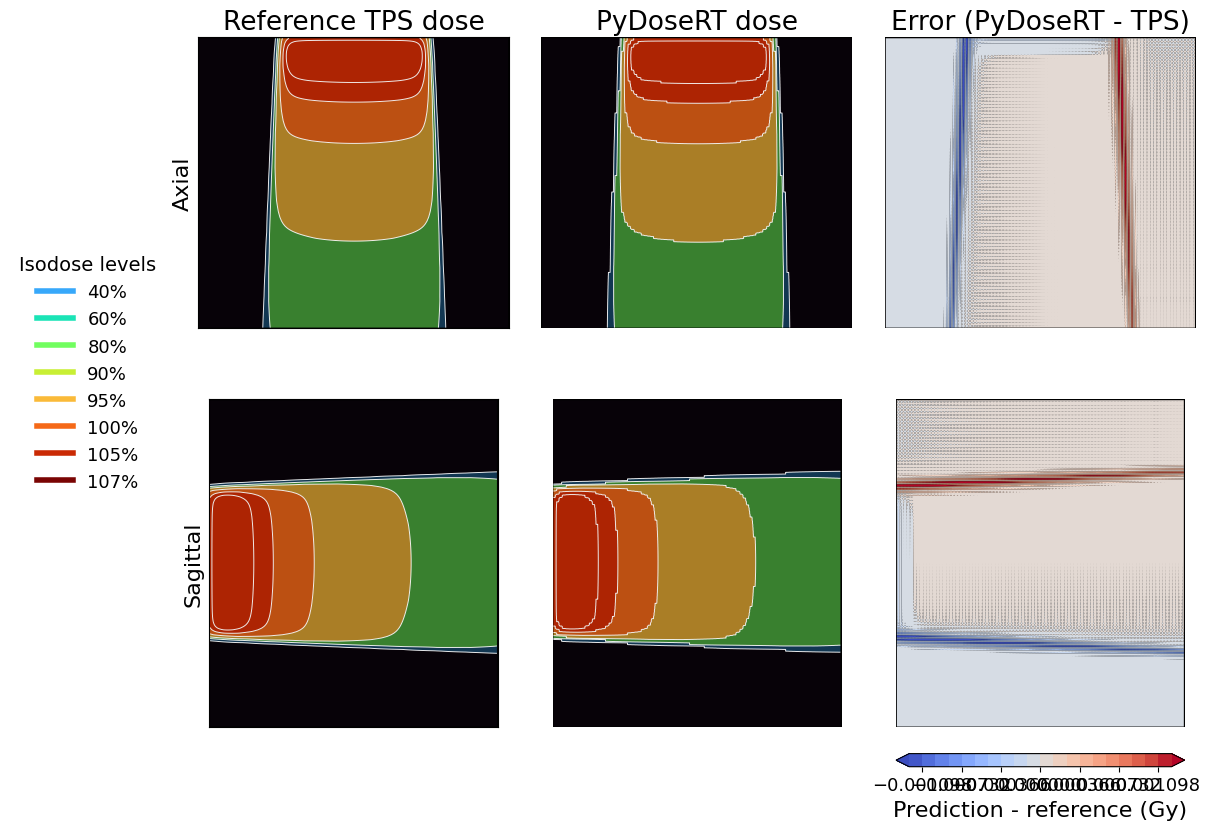

In [6]:
# High-res vs its own 2x-downsampled-then-upsampled version.
hr_ds = dose_hr[0, ::2, ::2, ::2]
hr_ds_up = np.repeat(np.repeat(np.repeat(hr_ds, 2, 0), 2, 1), 2, 2)
plot_overview(ph, dose_pred=torch.from_numpy(hr_ds_up), dvh=False)